In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

print("Setup complete!")
print("yfinance version:", yf.__version__)

Setup complete!
yfinance version: 1.5.2


In [2]:
# Download 5 years of Apple stock data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

df = yf.download('AAPL', start=start_date, end=end_date)

print(f"Downloaded {len(df)} trading days of AAPL data")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 1254 trading days of AAPL data
Date range: 2021-08-12 to 2026-08-11


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-08-12,145.222977,145.379040,142.248092,142.589478,72282600
2021-08-13,145.427826,145.759449,144.618266,145.301023,59375000
2021-08-16,147.398117,147.466400,142.862646,144.881657,103296000
2021-08-17,146.490967,147.944260,145.418053,146.529975,92229700
2021-08-18,142.755295,147.007913,142.550460,146.110573,86326000


In [3]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1254, 5)

Data types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [4]:
# Flatten the MultiIndex columns (since we only have one ticker)
df.columns = df.columns.get_level_values(0)

print("Columns now:", df.columns.tolist())
df.head()

Columns now: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-08-12,145.222977,145.379040,142.248092,142.589478,72282600
2021-08-13,145.427826,145.759449,144.618266,145.301023,59375000
2021-08-16,147.398117,147.466400,142.862646,144.881657,103296000
2021-08-17,146.490967,147.944260,145.418053,146.529975,92229700
2021-08-18,142.755295,147.007913,142.550460,146.110573,86326000


In [5]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Reset index so Date becomes a normal column
df = df.reset_index()

print(f"\nDataframe shape after reset: {df.shape}")
df.head()

Duplicate rows: 0

Dataframe shape after reset: (1254, 6)


Price,Date,Close,High,Low,Open,Volume
0,2021-08-12,145.222977,145.379040,142.248092,142.589478,72282600
1,2021-08-13,145.427826,145.759449,144.618266,145.301023,59375000
2,2021-08-16,147.398117,147.466400,142.862646,144.881657,103296000
3,2021-08-17,146.490967,147.944260,145.418053,146.529975,92229700
4,2021-08-18,142.755295,147.007913,142.550460,146.110573,86326000


In [6]:
# Check if Adj Close is missing, and if so, re-download with it included
df_raw = yf.download('AAPL', start=start_date, end=end_date, auto_adjust=False)
df_raw.columns = df_raw.columns.get_level_values(0)
print(df_raw.columns.tolist())
df_raw.head()

[*********************100%***********************]  1 of 1 completed

['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-08-12,145.223007,148.889999,149.050003,145.839996,146.190002,72282600
2021-08-13,145.427841,149.100006,149.440002,148.270004,148.970001,59375000
2021-08-16,147.398102,151.119995,151.190002,146.470001,148.539993,103296000
2021-08-17,146.490997,150.190002,151.679993,149.089996,150.229996,92229700
2021-08-18,142.755325,146.360001,150.720001,146.149994,149.800003,86326000


In [7]:
# Use the raw dataset (with both Close and Adj Close) as our main dataframe
df = df_raw.copy()

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Shape: (1254, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-08-12,145.223007,148.889999,149.050003,145.839996,146.190002,72282600
2021-08-13,145.427841,149.100006,149.440002,148.270004,148.970001,59375000
2021-08-16,147.398102,151.119995,151.190002,146.470001,148.539993,103296000
2021-08-17,146.490997,150.190002,151.679993,149.089996,150.229996,92229700
2021-08-18,142.755325,146.360001,150.720001,146.149994,149.800003,86326000


In [8]:
# Reset index so Date becomes a normal column
df = df.reset_index()

print(f"\nDataframe shape after reset: {df.shape}")
df.head()


Dataframe shape after reset: (1254, 7)


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-12,145.223007,148.889999,149.050003,145.839996,146.190002,72282600
1,2021-08-13,145.427841,149.100006,149.440002,148.270004,148.970001,59375000
2,2021-08-16,147.398102,151.119995,151.190002,146.470001,148.539993,103296000
3,2021-08-17,146.490997,150.190002,151.679993,149.089996,150.229996,92229700
4,2021-08-18,142.755325,146.360001,150.720001,146.149994,149.800003,86326000


In [9]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate rows: 0


In [10]:
print("Price Statistics (USD):")
print(f"  Minimum Adj Close Price: ${df['Adj Close'].min():.2f}")
print(f"  Maximum Adj Close Price: ${df['Adj Close'].max():.2f}")
print(f"  Average Adj Close Price: ${df['Adj Close'].mean():.2f}")
print(f"  Current Adj Close Price (latest): ${df['Adj Close'].iloc[-1]:.2f}")

print("\nVolume Statistics (shares):")
print(f"  Average Daily Volume: {df['Volume'].mean():,.0f}")
print(f"  Min Volume: {df['Volume'].min():,.0f}")
print(f"  Max Volume: {df['Volume'].max():,.0f}")

Price Statistics (USD):
  Minimum Adj Close Price: $122.83
  Maximum Adj Close Price: $339.79
  Average Adj Close Price: $197.65
  Current Adj Close Price (latest): $306.47

Volume Statistics (shares):
  Average Daily Volume: 64,641,634
  Min Volume: 9,421,641
  Max Volume: 318,679,900


In [11]:
# Daily Price Change (in dollars) - using Adj Close
df['Daily_Price_Change'] = df['Adj Close'].diff()

# Daily Percentage Change (in %)
df['Daily_Pct_Change'] = df['Adj Close'].pct_change() * 100

# High-Low Range (intraday volatility)
df['Daily_Range'] = df['High'] - df['Low']

print("New columns created:")
print(df[['Date', 'Adj Close', 'Daily_Price_Change', 'Daily_Pct_Change', 'Daily_Range']].head(10))

New columns created:
Price       Date   Adj Close  Daily_Price_Change  Daily_Pct_Change  \
0     2021-08-12  145.223007                 NaN               NaN   
1     2021-08-13  145.427841            0.204834          0.141048   
2     2021-08-16  147.398102            1.970261          1.354803   
3     2021-08-17  146.490997           -0.907104         -0.615411   
4     2021-08-18  142.755325           -3.735672         -2.550103   
5     2021-08-19  143.086929            0.331604          0.232288   
6     2021-08-20  144.540268            1.453339          1.015703   
7     2021-08-23  146.022781            1.482513          1.025675   
8     2021-08-24  145.935028           -0.087753         -0.060096   
9     2021-08-25  144.706055           -1.228973         -0.842137   

Price  Daily_Range  
0         3.210007  
1         1.169998  
2         4.720001  
3         2.589996  
4         4.570007  
5         3.500000  
6         1.720001  
7         2.300003  
8         1.710007 

In [12]:
# 7-day Moving Average
df['MA_7'] = df['Adj Close'].rolling(window=7).mean()

# 30-day Moving Average
df['MA_30'] = df['Adj Close'].rolling(window=30).mean()

print("Moving Averages created:")
print(df[['Date', 'Adj Close', 'MA_7', 'MA_30']].tail(10))

Moving Averages created:
Price       Date   Adj Close        MA_7       MA_30
1244  2026-07-29  337.898590  331.641122  311.585608
1245  2026-07-30  333.142670  332.453278  312.724292
1246  2026-07-31  308.643829  330.029654  313.155920
1247  2026-08-03  303.158569  327.426187  313.336099
1248  2026-08-04  309.113403  324.051954  313.748076
1249  2026-08-05  310.732025  320.353716  314.304264
1250  2026-08-06  312.140808  316.404271  314.948044
1251  2026-08-07  313.059998  312.855900  316.219614
1252  2026-08-10  308.260010  309.301235  317.043765
1253  2026-08-11  306.470001  308.990688  317.876191


In [13]:
# Rolling 30-day Volatility
df['Volatility_30d'] = df['Daily_Pct_Change'].rolling(window=30).std()

print("Volatility feature created:")
print(df[['Date', 'Daily_Pct_Change', 'Volatility_30d']].tail(10))

Volatility feature created:
Price       Date  Daily_Pct_Change  Volatility_30d
1244  2026-07-29         -0.555741        2.073040
1245  2026-07-30         -1.407499        2.098389
1246  2026-07-31         -7.353858        2.519212
1247  2026-08-03         -1.777214        2.541909
1248  2026-08-04          1.964264        2.563171
1249  2026-08-05          0.523634        2.555689
1250  2026-08-06          0.453376        2.553214
1251  2026-08-07          0.294479        2.252916
1252  2026-08-10         -1.533249        2.222654
1253  2026-08-11         -0.580681        2.220605


In [14]:
# Extract Year-Month for grouping
df['Month'] = df['Date'].dt.to_period('M')

# Sum daily % changes within each month (approximation of monthly return)
monthly_returns = df.groupby('Month')['Daily_Pct_Change'].sum()

# Merge back into main dataframe
df = df.merge(
    monthly_returns.rename('Monthly_Return').reset_index(),
    on='Month',
    how='left'
)

print("Monthly Returns (first 10 months):")
print(monthly_returns.head(10))

Monthly Returns (first 10 months):
Month
2021-08     2.066776
2021-09    -6.860920
2021-10     5.847855
2021-11    10.227468
2021-12     7.528482
2022-01    -1.132287
2022-02    -5.345007
2022-03     6.031263
2022-04    -9.756355
2022-05    -4.619786
Freq: M, Name: Daily_Pct_Change, dtype: float64


In [15]:
# Overall 5-year trend
recent_price = df['Adj Close'].iloc[-1]
oldest_price = df['Adj Close'].iloc[0]
total_gain = ((recent_price - oldest_price) / oldest_price) * 100

print(f"Price 5 years ago: ${oldest_price:.2f}")
print(f"Price today: ${recent_price:.2f}")
print(f"Total gain over period: {total_gain:.2f}%")

# Year-over-year summary
df['Year'] = df['Date'].dt.year
yearly_summary = df.groupby('Year')['Adj Close'].agg(['first', 'last', 'min', 'max'])
yearly_summary['Annual_Return_%'] = ((yearly_summary['last'] - yearly_summary['first']) / yearly_summary['first']) * 100

print("\nYearly Summary:")
print(yearly_summary.round(2))

Price 5 years ago: $145.22
Price today: $306.47
Total gain over period: 111.03%

Yearly Summary:
       first    last     min     max  Annual_Return_%
Year                                                 
2021  145.22  173.45  135.71  176.15            19.44
2022  177.79  127.65  123.83  177.79           -28.20
2023  122.88  190.21  122.83  195.72            54.80
2024  183.40  248.62  163.22  257.15            35.56
2025  242.09  271.12  171.37  285.41            11.99
2026  270.27  306.47  246.03  339.79            13.39


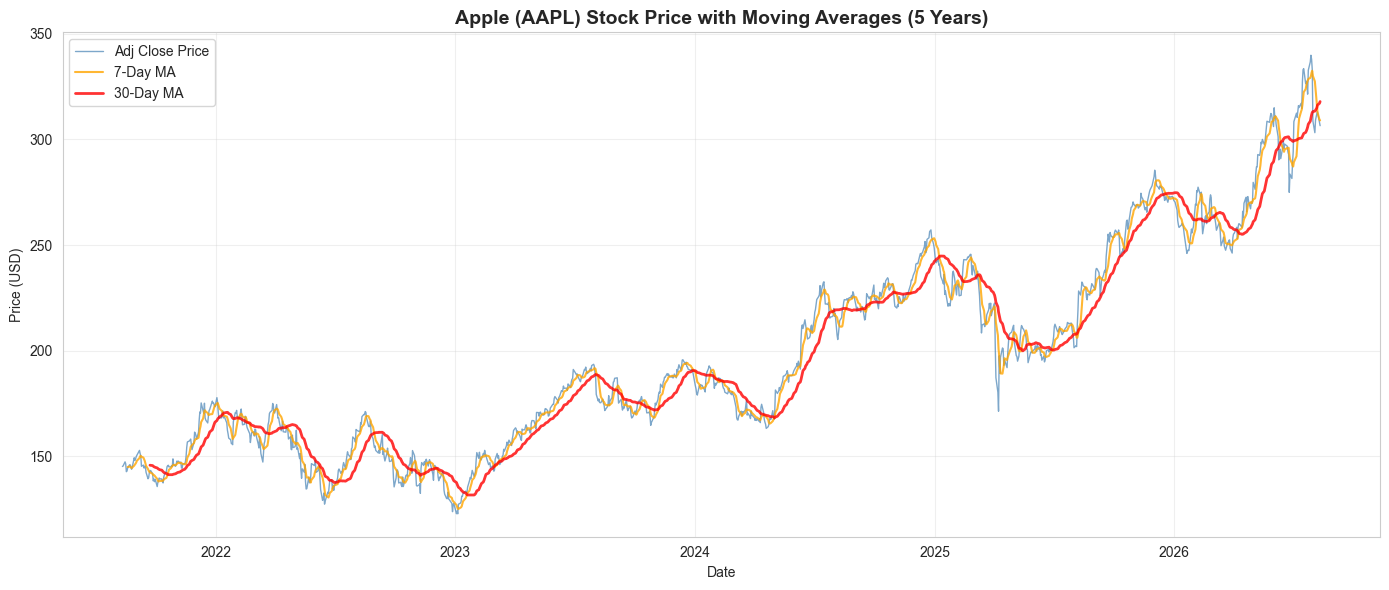

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Adj Close'], label='Adj Close Price', color='steelblue', linewidth=1, alpha=0.7)
plt.plot(df['Date'], df['MA_7'], label='7-Day MA', color='orange', linewidth=1.5, alpha=0.8)
plt.plot(df['Date'], df['MA_30'], label='30-Day MA', color='red', linewidth=2, alpha=0.8)

plt.title('Apple (AAPL) Stock Price with Moving Averages (5 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

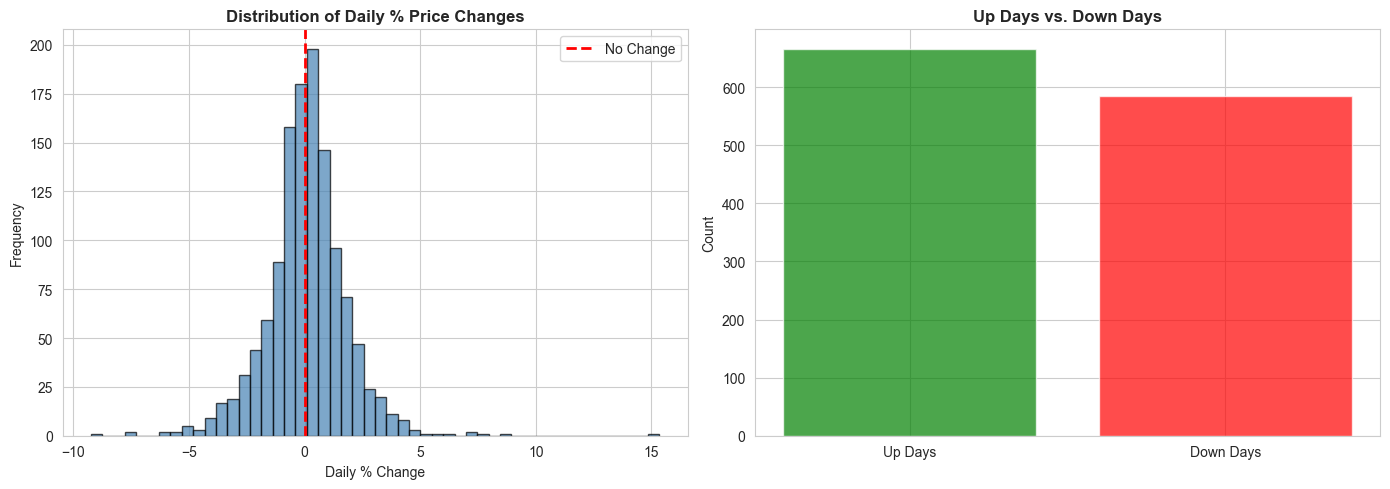

Up days: 666 (53.3%)
Down days: 584 (46.7%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of daily % changes
axes[0].hist(df['Daily_Pct_Change'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[0].set_title('Distribution of Daily % Price Changes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daily % Change')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Up days vs down days
up_days = (df['Daily_Pct_Change'] > 0).sum()
down_days = (df['Daily_Pct_Change'] < 0).sum()
axes[1].bar(['Up Days', 'Down Days'], [up_days, down_days], color=['green', 'red'], alpha=0.7)
axes[1].set_title('Up Days vs. Down Days', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Up days: {up_days} ({100*up_days/(up_days+down_days):.1f}%)")
print(f"Down days: {down_days} ({100*down_days/(up_days+down_days):.1f}%)")

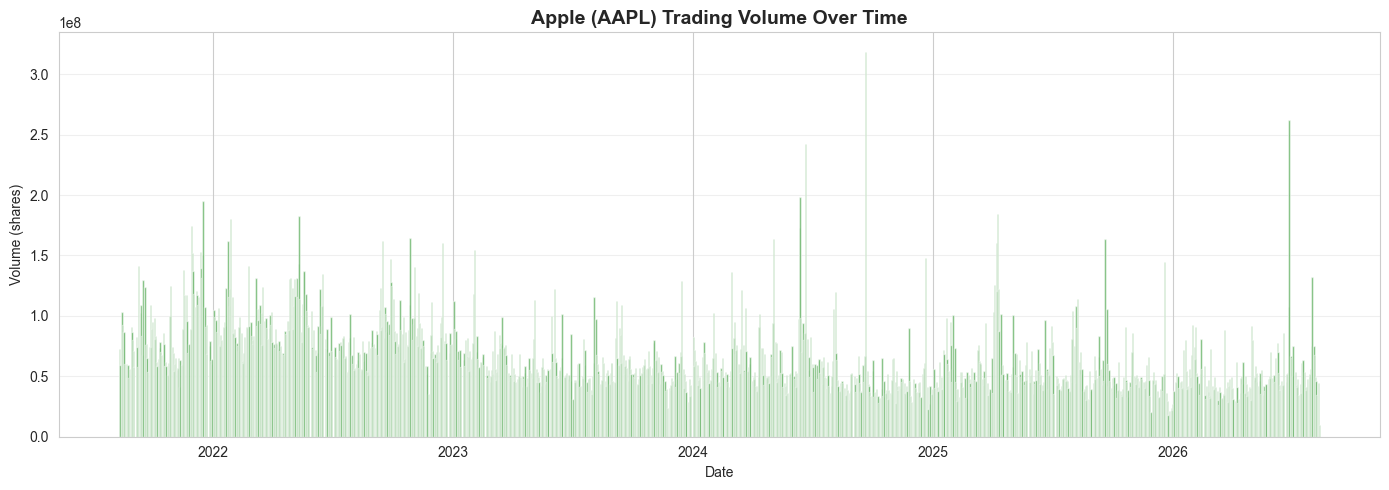

Average Daily Volume: 64,641,634 shares
Median Daily Volume: 56,292,550 shares


In [18]:
plt.figure(figsize=(14, 5))

plt.bar(df['Date'], df['Volume'], color='green', alpha=0.6, width=2)
plt.title('Apple (AAPL) Trading Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume (shares)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Average Daily Volume: {df['Volume'].mean():,.0f} shares")
print(f"Median Daily Volume: {df['Volume'].median():,.0f} shares")

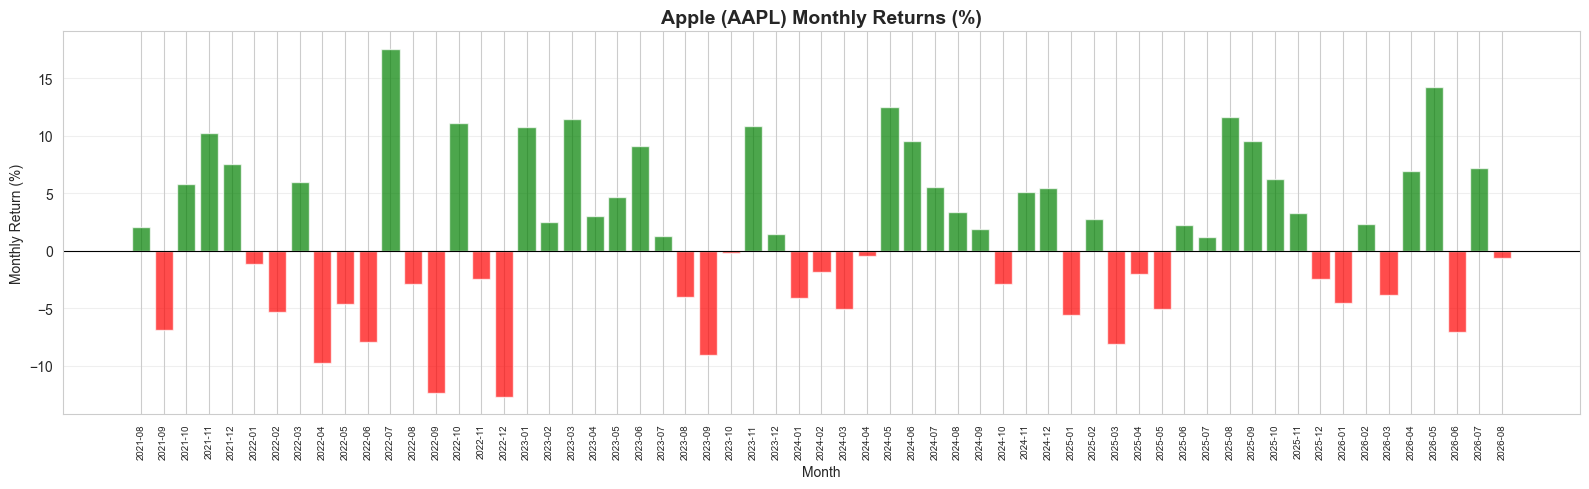

In [19]:
# Get one row per month with its return (avoid duplicate counting)
monthly_returns_unique = df.groupby('Month')['Daily_Pct_Change'].sum()

plt.figure(figsize=(16, 5))
colors = ['green' if x > 0 else 'red' for x in monthly_returns_unique.values]
plt.bar(monthly_returns_unique.index.astype(str), monthly_returns_unique.values, color=colors, alpha=0.7)

plt.title('Apple (AAPL) Monthly Returns (%)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')
plt.xticks(rotation=90, fontsize=7)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [20]:
print("=== KEY FINDINGS: APPLE (AAPL) STOCK ANALYSIS ===\n")

print("1. OVERALL TREND")
print(f"   • 5-year price change: {total_gain:.2f}% (${oldest_price:.2f} → ${recent_price:.2f})")
print(f"   • Best year: 2023 (+54.80%)")
print(f"   • Worst year: 2022 (-28.20%)")

print("\n2. DAILY MOVEMENT")
win_rate = 100*up_days/(up_days+down_days)
print(f"   • Up days: {up_days} ({win_rate:.1f}%)")
print(f"   • Down days: {down_days} ({100-win_rate:.1f}%)")
print(f"   • Average daily swing: ±{df['Daily_Pct_Change'].std():.2f}%")

print("\n3. VOLATILITY")
print(f"   • Average 30-day volatility: {df['Volatility_30d'].mean():.2f}%")
print(f"   • Current 30-day volatility: {df['Volatility_30d'].iloc[-1]:.2f}%")

print("\n4. TRADING ACTIVITY")
print(f"   • Average daily volume: {df['Volume'].mean():,.0f} shares")
print(f"   • Peak volume day: {df['Volume'].max():,.0f} shares")

print("\n5. MOVING AVERAGE SIGNAL (as of latest data)")
latest_close = df['Adj Close'].iloc[-1]
latest_ma7 = df['MA_7'].iloc[-1]
latest_ma30 = df['MA_30'].iloc[-1]
print(f"   • Current Price: ${latest_close:.2f}")
print(f"   • 7-Day MA: ${latest_ma7:.2f}")
print(f"   • 30-Day MA: ${latest_ma30:.2f}")
position = "above" if latest_close > latest_ma30 else "below"
print(f"   • Signal: Price is currently {position} its 30-day trend")

=== KEY FINDINGS: APPLE (AAPL) STOCK ANALYSIS ===

1. OVERALL TREND
   • 5-year price change: 111.03% ($145.22 → $306.47)
   • Best year: 2023 (+54.80%)
   • Worst year: 2022 (-28.20%)

2. DAILY MOVEMENT
   • Up days: 666 (53.3%)
   • Down days: 584 (46.7%)
   • Average daily swing: ±1.77%

3. VOLATILITY
   • Average 30-day volatility: 1.66%
   • Current 30-day volatility: 2.22%

4. TRADING ACTIVITY
   • Average daily volume: 64,641,634 shares
   • Peak volume day: 318,679,900 shares

5. MOVING AVERAGE SIGNAL (as of latest data)
   • Current Price: $306.47
   • 7-Day MA: $308.99
   • 30-Day MA: $317.88
   • Signal: Price is currently below its 30-day trend
